# 05 — Evaluation
**Objectif :** Mesurer les performances du modèle sur le test set.

Métriques :
- Accuracy
- F1-score
- Precision & Recall
- Matrice de confusion
- Analyse des erreurs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

c:\Users\akrou\anaconda3\envs\RAG\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.25). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


## 1. Charger le modèle et les données de test

In [2]:
model   = load_model('models/best_model.keras')
X_test  = np.load('data/X_test.npy')
y_test  = np.load('data/y_test.npy')

print(f'Test set : {X_test.shape[0]} images')

Test set : 281 images


## 2. Prédictions

In [3]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

print(f'Exemples de probabilités : {y_pred_proba[:5].flatten()}')
print(f'Prédictions              : {y_pred[:5]}')
print(f'Vérité terrain           : {y_test[:5].astype(int)}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Exemples de probabilités : [0.9987958  0.08767615 0.9999908  0.99249405 0.52867484]
Prédictions              : [1 0 1 1 1]
Vérité terrain           : [1 0 1 1 0]


## 3. Métriques de performance

In [4]:
acc       = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print('=' * 40)
print(f'Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'F1-score  : {f1:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print('=' * 40)
print()
print('Rapport complet :')
print(classification_report(y_test, y_pred, target_names=['no tumor', 'tumor']))

Accuracy  : 0.8932  (89.3%)
F1-score  : 0.9096
Precision : 0.8935
Recall    : 0.9264

Rapport complet :
              precision    recall  f1-score   support

    no tumor       0.89      0.85      0.87       118
       tumor       0.89      0.93      0.91       163

    accuracy                           0.89       281
   macro avg       0.89      0.89      0.89       281
weighted avg       0.89      0.89      0.89       281



## 4. Matrice de confusion

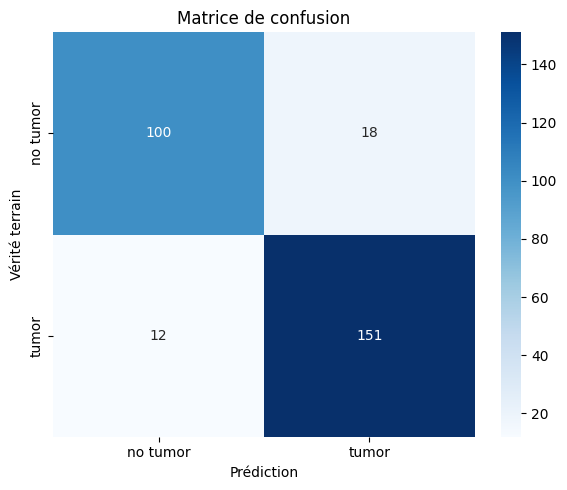

Vrais Positifs  (TP) : 151  — tumeurs correctement détectées
Vrais Négatifs  (TN) : 100  — sains correctement identifiés
Faux Positifs   (FP) : 18  — sains détectés comme tumeur
Faux Négatifs   (FN) : 12  — tumeurs manquées (le plus grave !)


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['no tumor', 'tumor'],
    yticklabels=['no tumor', 'tumor']
)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité terrain')
ax.set_title('Matrice de confusion')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais Positifs  (TP) : {tp}  — tumeurs correctement détectées')
print(f'Vrais Négatifs  (TN) : {tn}  — sains correctement identifiés')
print(f'Faux Positifs   (FP) : {fp}  — sains détectés comme tumeur')
print(f'Faux Négatifs   (FN) : {fn}  — tumeurs manquées (le plus grave !)')

## 5. Analyse des erreurs — visualiser les cas mal classés

Nombre d'erreurs : 30 sur 281 images


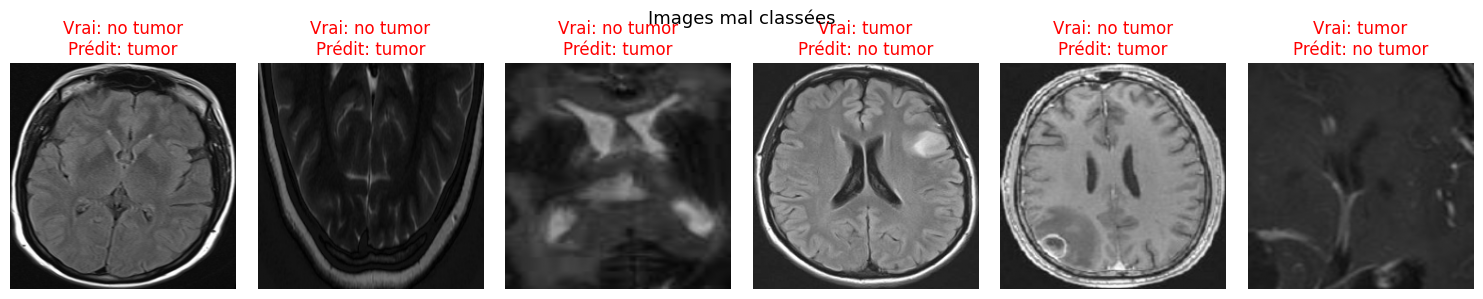

In [6]:
errors = np.where(y_pred != y_test)[0]
print(f'Nombre d\'erreurs : {len(errors)} sur {len(y_test)} images')

n_show = min(6, len(errors))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
    if n_show == 1:
        axes = [axes]
    for i, idx in enumerate(errors[:n_show]):
        axes[i].imshow(X_test[idx])
        axes[i].set_title(
            f'Vrai: {"tumor" if y_test[idx]==1 else "no tumor"}\n'
            f'Prédit: {"tumor" if y_pred[idx]==1 else "no tumor"}',
            color='red'
        )
        axes[i].axis('off')
    plt.suptitle('Images mal classées', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Aucune erreur !')